# Análise Individual — Tuning do Modelo Campeão

**Disciplina:** Análise de Dados  
**Projeto:** DATA STORM — Sífilis Congênita em Minas Gerais  
**Aluno:** Gustavo Correia Scarabeli — 082210030
**Data:** Abril de 2026

---

### Contexto

O grupo definiu a **Regressão Logística** como modelo campeão na Entrega 3, com base no maior AUC-ROC (0.6958) entre os quatro algoritmos testados. Este notebook realiza uma análise crítica individual sobre a estabilidade desse modelo, cobrindo:

1. Reprodução do modelo original do grupo (baseline)
2. Tuning de três hiperparâmetros e comparação de resultados
3. Teste de estresse: remoção da variável mais importante identificada na EDA
4. Análise crítica dos resultados

---

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/DATA_STORM_Project'
PROC = f'{BASE}/data/processed'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip install -q pyarrow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score,
    confusion_matrix, roc_curve, classification_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

## 1. Carregamento e Preparação dos Dados

Os dados são carregados diretamente das tabelas do Star Schema geradas na Entrega 1, garantindo que o pré-processamento seja idêntico ao do notebook do grupo.

In [6]:
fato      = pd.read_parquet(f'{PROC}/fato_casos.parquet')
dim_tempo = pd.read_parquet(f'{PROC}/dim_tempo.parquet')
dim_local = pd.read_parquet(f'{PROC}/dim_local.parquet')
dim_pac   = pd.read_parquet(f'{PROC}/dim_paciente.parquet')
dim_clin  = pd.read_parquet(f'{PROC}/dim_clinico.parquet')

df = fato.merge(dim_tempo, on='id_tempo')\
         .merge(dim_local, on='id_local')\
         .merge(dim_pac,   on='id_paciente')\
         .merge(dim_clin,  on='id_clinico')

print(f'Dataset carregado: {df.shape}')

Dataset carregado: (33345, 19)


In [7]:
FEATURES_NUM = ['nu_idade_n']
FEATURES_CAT = ['sexo', 'raca_cor', 'faixa_etaria',
                 'momento_diag_materno', 'esquema_tratamento', 'labc_igg']
TARGET = 'obito_sifilis'

df_model = df[FEATURES_NUM + FEATURES_CAT + [TARGET]].dropna(subset=[TARGET]).copy()

X = df_model.drop(TARGET, axis=1)
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}')
print(f'Taxa de óbito (target=1): {y.mean()*100:.2f}%')

Treino: 26,676 | Teste: 6,669
Taxa de óbito (target=1): 1.34%


In [8]:
def build_pipeline(model):
    num_t = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ])
    cat_t = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    prep = ColumnTransformer([
        ('num', num_t, FEATURES_NUM),
        ('cat', cat_t, FEATURES_CAT)
    ])
    return Pipeline([('prep', prep), ('clf', model)])


def evaluate(pipe, X_tr, y_tr, X_te, y_te, label=''):
    t0 = time.time()
    pipe.fit(X_tr, y_tr)
    t_ms = (time.time() - t0) * 1000

    y_pred = pipe.predict(X_te)
    y_prob = pipe.predict_proba(X_te)[:, 1]

    resultado = {
        'Label':      label,
        'Acurácia':   round(accuracy_score(y_te, y_pred), 4),
        'Precisão':   round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall':     round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1-Score':   round(f1_score(y_te, y_pred, zero_division=0), 4),
        'AUC-ROC':    round(roc_auc_score(y_te, y_prob), 4),
        'Tempo (ms)': round(t_ms, 0),
    }
    return resultado, pipe

print('Funções auxiliares definidas.')

Funções auxiliares definidas.


---
## 2. Modelo Original do Grupo (Baseline)

Reprodução exata do modelo campeão da Entrega 3 para servir como referência de comparação.

**Hiperparâmetros originais:**
- `C = 1.0` (regularização padrão do sklearn)
- `penalty = 'l2'` (Ridge)
- `solver = 'lbfgs'`
- `class_weight = 'balanced'`
- `max_iter = 1000`

In [9]:
modelo_original = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

pipe_original = build_pipeline(modelo_original)
res_original, pipe_original = evaluate(pipe_original, X_train, y_train, X_test, y_test,
                                        label='Original (grupo)')

print('Resultado do modelo original:')
for k, v in res_original.items():
    print(f'  {k}: {v}')

Resultado do modelo original:
  Label: Original (grupo)
  Acurácia: 0.7209
  Precisão: 0.0247
  Recall: 0.5111
  F1-Score: 0.0471
  AUC-ROC: 0.6958
  Tempo (ms): 691.0


---
## 3. Tuning de Hiperparâmetros

Três hiperparâmetros foram alterados de forma deliberada — cada um com uma justificativa diferente — para entender a sensibilidade do modelo a cada eixo de ajuste.

**Hiperparâmetros modificados:**

| # | Hiperparâmetro | Original | Otimizado | Justificativa |
|---|---|---|---|---|
| 1 | `C` (inverso da regularização) | 1.0 | 0.01 | Aumenta a regularização; reduz overfitting em datasets desbalanceados |
| 2 | `penalty` | `'l2'` | `'l1'` | L1 induz esparsidade — descarta features irrelevantes automaticamente |
| 3 | `solver` | `'lbfgs'` | `'saga'` | Necessário para L1; suporta datasets grandes com convergência mais estável |

A lógica por trás dessa combinação é testar se um modelo mais regularizado, que descarta variáveis automaticamente via L1, captura melhor o sinal do target em um dataset com classe minoritária de ~1,3%.

In [10]:
# Variante 1: apenas C mais restritivo (regularização mais forte)
pipe_v1, res_v1 = build_pipeline(
    LogisticRegression(C=0.01, penalty='l2', solver='lbfgs',
                       class_weight='balanced', max_iter=2000, random_state=42)
), None
res_v1, pipe_v1 = evaluate(pipe_v1, X_train, y_train, X_test, y_test,
                            label='C=0.01, L2')

# Variante 2: L1 com saga (esparsidade)
pipe_v2, res_v2 = build_pipeline(
    LogisticRegression(C=1.0, penalty='l1', solver='saga',
                       class_weight='balanced', max_iter=2000, random_state=42)
), None
res_v2, pipe_v2 = evaluate(pipe_v2, X_train, y_train, X_test, y_test,
                            label='C=1.0, L1, saga')

# Variante 3: combinação — C restritivo + L1 + saga (modelo otimizado final)
pipe_v3, res_v3 = build_pipeline(
    LogisticRegression(C=0.01, penalty='l1', solver='saga',
                       class_weight='balanced', max_iter=2000, random_state=42)
), None
res_v3, pipe_v3 = evaluate(pipe_v3, X_train, y_train, X_test, y_test,
                            label='C=0.01, L1, saga (otimizado)')

print('Tuning concluído.')

Tuning concluído.


---
## 4. Teste de Estresse — Remoção da Variável Mais Importante

Na Entrega 2, a análise do target mostrou que `esquema_tratamento` é a variável com maior diferença na taxa de óbito entre suas categorias (tratamento adequado vs. não realizado). Este bloco treina o modelo otimizado sem essa variável para medir o quanto ela contribui isoladamente para o AUC-ROC.

In [11]:
FEATURES_CAT_STRESS = [f for f in FEATURES_CAT if f != 'esquema_tratamento']

def build_pipeline_custom(model, num_feats, cat_feats):
    num_t = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ])
    cat_t = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    prep = ColumnTransformer([
        ('num', num_t, num_feats),
        ('cat', cat_t, cat_feats)
    ])
    return Pipeline([('prep', prep), ('clf', model)])

X_stress = df_model[FEATURES_NUM + FEATURES_CAT_STRESS]
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_stress, y, test_size=0.20, random_state=42, stratify=y
)

pipe_stress = build_pipeline_custom(
    LogisticRegression(C=0.01, penalty='l1', solver='saga',
                       class_weight='balanced', max_iter=2000, random_state=42),
    FEATURES_NUM, FEATURES_CAT_STRESS
)
res_stress, pipe_stress = evaluate(pipe_stress, X_tr_s, y_tr_s, X_te_s, y_te_s,
                                    label='Otimizado SEM esquema_tratamento')

print('Teste de estresse concluído.')
print(f'  AUC-ROC (com esquema_tratamento):  {res_v3["AUC-ROC"]}')
print(f'  AUC-ROC (sem esquema_tratamento):  {res_stress["AUC-ROC"]}')
variacao = (res_stress['AUC-ROC'] - res_v3['AUC-ROC']) / res_v3['AUC-ROC'] * 100
print(f'  Variacao: {variacao:+.2f}%')

Teste de estresse concluído.
  AUC-ROC (com esquema_tratamento):  0.6919
  AUC-ROC (sem esquema_tratamento):  0.6762
  Variacao: -2.27%


---
## 5. Comparativo Completo

In [12]:
todos = [res_original, res_v1, res_v2, res_v3, res_stress]
df_comp = pd.DataFrame(todos).set_index('Label')

print('Tabela Comparativa — Todos os Cenários:')
print(df_comp.to_string())

Tabela Comparativa — Todos os Cenários:
                                  Acurácia  Precisão  Recall  F1-Score  AUC-ROC  Tempo (ms)
Label                                                                                      
Original (grupo)                    0.7209    0.0247  0.5111    0.0471   0.6958       691.0
C=0.01, L2                          0.7206    0.0247  0.5111    0.0471   0.6934       551.0
C=1.0, L1, saga                     0.7223    0.0248  0.5111    0.0473   0.6958     90629.0
C=0.01, L1, saga (otimizado)        0.7094    0.0257  0.5556    0.0491   0.6919     18673.0
Otimizado SEM esquema_tratamento    0.6827    0.0249  0.5889    0.0477   0.6762     14036.0


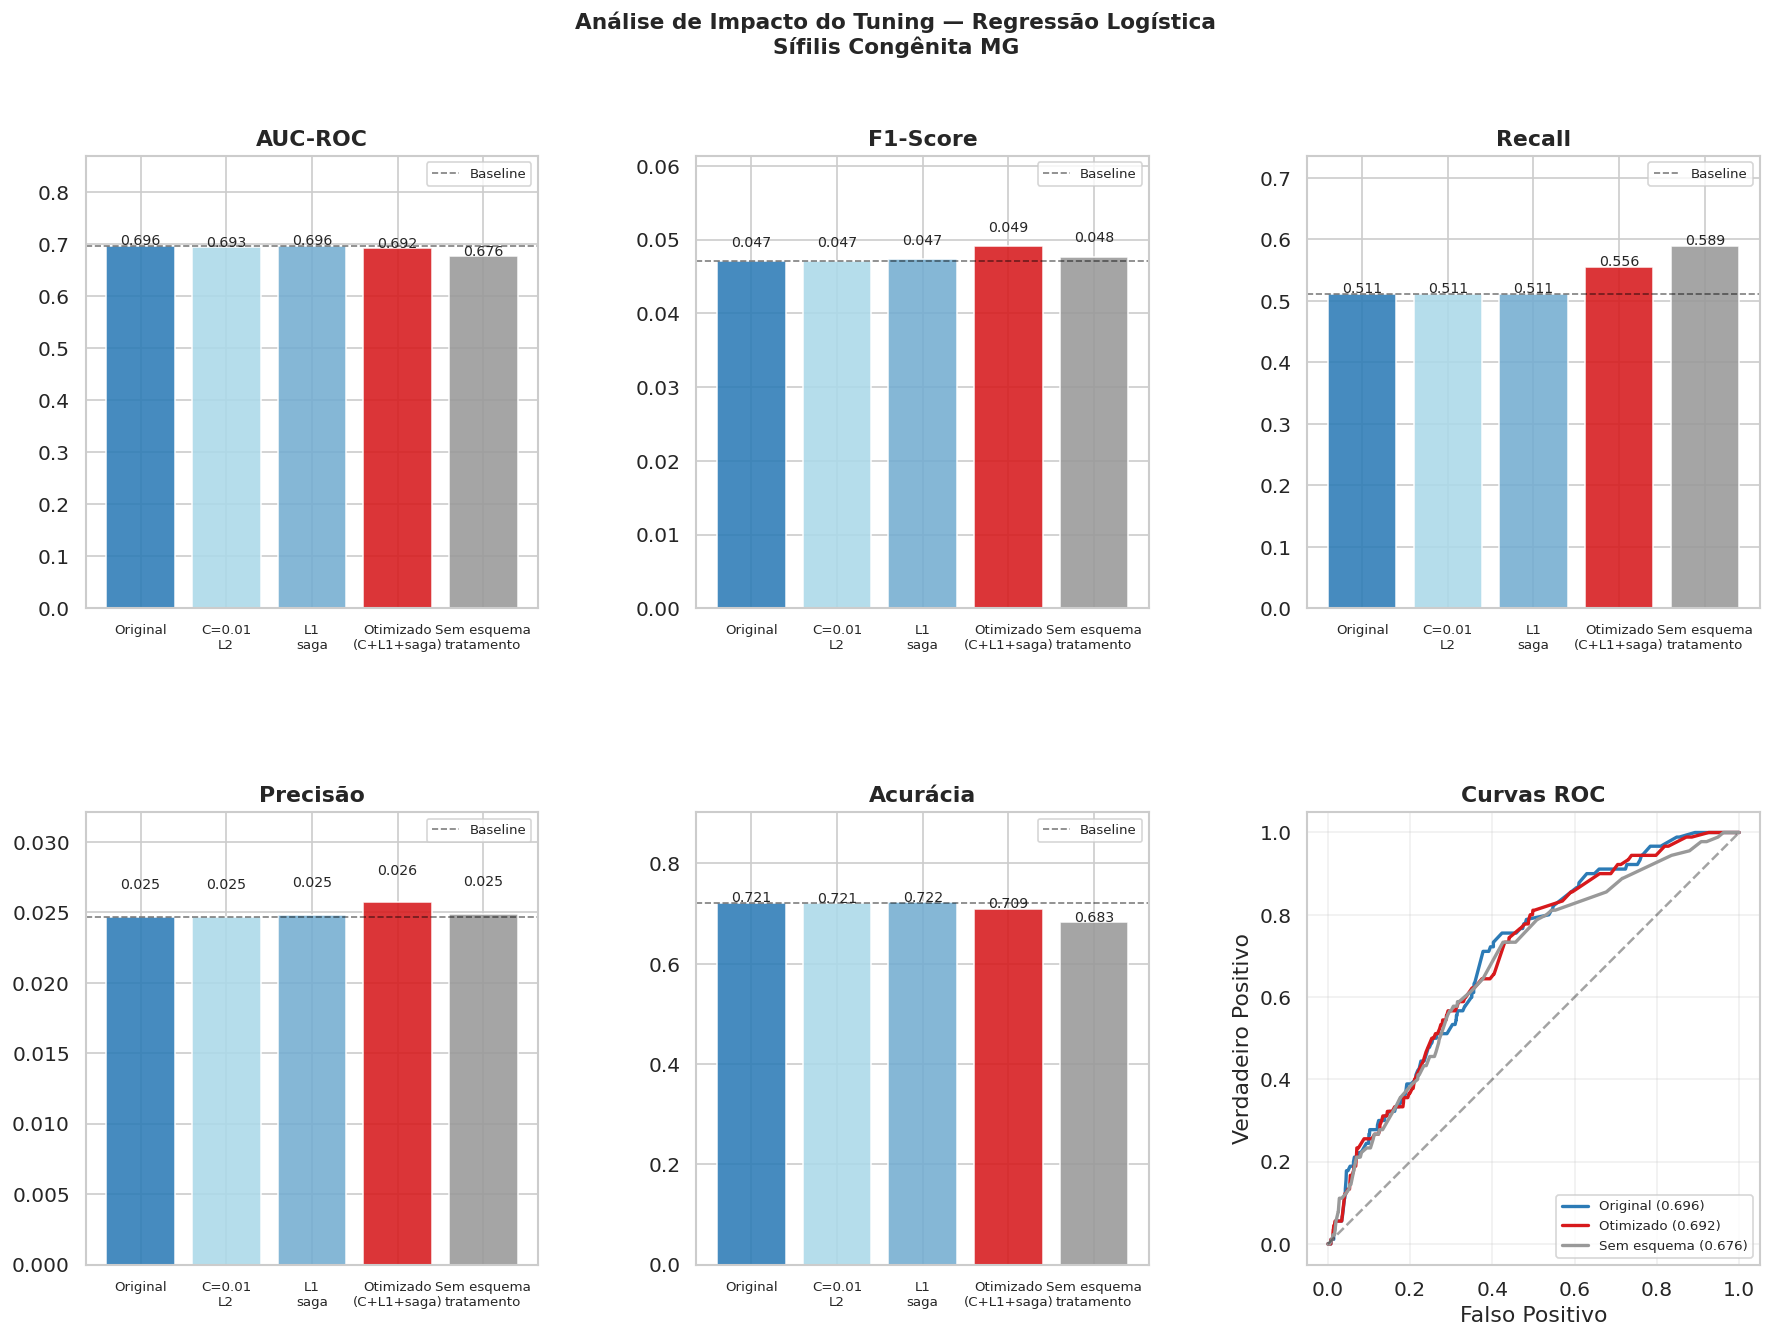

In [13]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

cores = ['#2c7bb6', '#abd9e9', '#74add1', '#d7191c', '#999999']
labels_curtos = ['Original', 'C=0.01\nL2', 'L1\nsaga', 'Otimizado\n(C+L1+saga)', 'Sem esquema\ntratamento']

metricas = ['AUC-ROC', 'F1-Score', 'Recall', 'Precisão', 'Acurácia']
posicoes = [(0,0), (0,1), (0,2), (1,0), (1,1)]

for metrica, pos in zip(metricas, posicoes):
    ax = fig.add_subplot(gs[pos[0], pos[1]])
    vals = df_comp[metrica].values
    bars = ax.bar(labels_curtos, vals, color=cores, edgecolor='white', alpha=0.88)
    ax.axhline(vals[0], color='black', linestyle='--', linewidth=1, alpha=0.5,
               label='Baseline')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=8.5)
    ax.set_title(metrica, fontweight='bold')
    ax.set_ylim(0, min(vals.max() * 1.25, 1.05))
    ax.tick_params(axis='x', labelsize=8)
    ax.legend(fontsize=8)

# Curvas ROC no último painel
ax_roc = fig.add_subplot(gs[1, 2])
cenarios_roc = [
    ('Original', pipe_original, X_test,  y_test,  '#2c7bb6'),
    ('Otimizado', pipe_v3,      X_test,  y_test,  '#d7191c'),
    ('Sem esquema', pipe_stress, X_te_s, y_te_s, '#999999'),
]
for label, pipe, Xte, yte, cor in cenarios_roc:
    fpr, tpr, _ = roc_curve(yte, pipe.predict_proba(Xte)[:, 1])
    auc = roc_auc_score(yte, pipe.predict_proba(Xte)[:, 1])
    ax_roc.plot(fpr, tpr, label=f'{label} ({auc:.3f})', color=cor, linewidth=2)
ax_roc.plot([0,1],[0,1], 'k--', alpha=0.4)
ax_roc.set_xlabel('Falso Positivo')
ax_roc.set_ylabel('Verdadeiro Positivo')
ax_roc.set_title('Curvas ROC', fontweight='bold')
ax_roc.legend(fontsize=8, loc='lower right')
ax_roc.grid(True, alpha=0.3)

fig.suptitle('Análise de Impacto do Tuning — Regressão Logística\nSífilis Congênita MG',
             fontsize=13, fontweight='bold')

plt.savefig(f'{PROC}/fig_tuning_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()

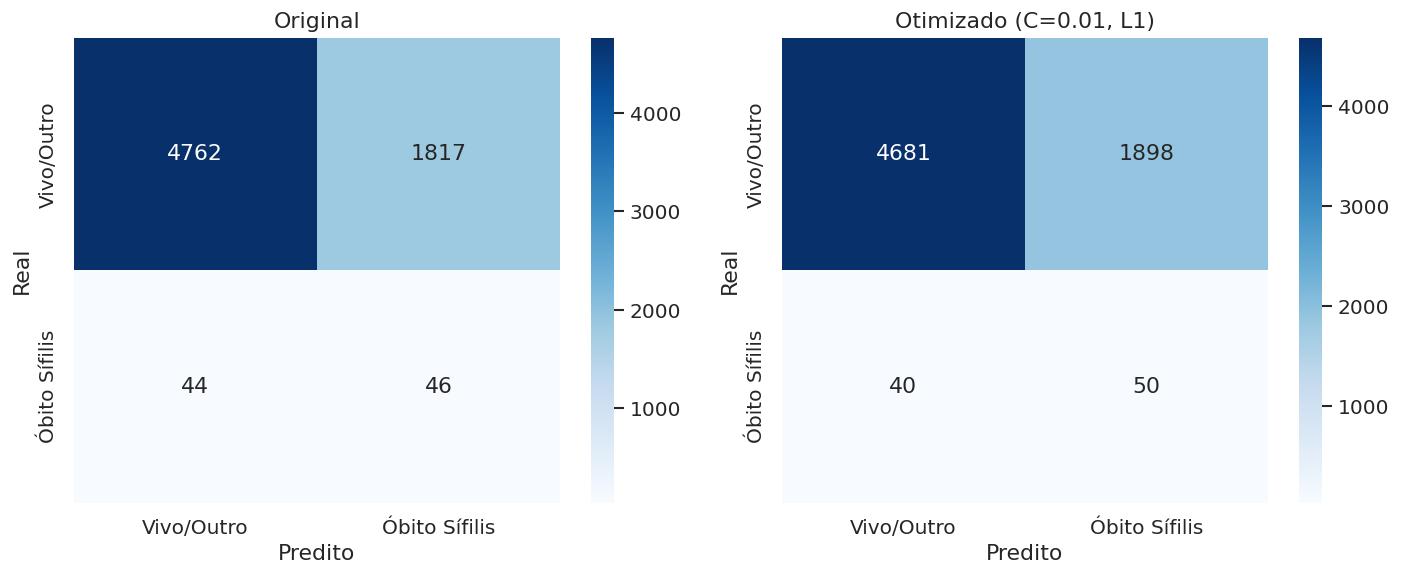

In [14]:
# Matrizes de confusão lado a lado: original vs. otimizado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, pipe, Xte, yte) in zip(axes, [
    ('Original', pipe_original, X_test, y_test),
    ('Otimizado (C=0.01, L1)', pipe_v3, X_test, y_test)
]):
    cm = confusion_matrix(yte, pipe.predict(Xte))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Vivo/Outro', 'Óbito Sífilis'],
                yticklabels=['Vivo/Outro', 'Óbito Sífilis'])
    ax.set_title(label)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')

plt.tight_layout()
plt.savefig(f'{PROC}/fig_confusion_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

Cross-Validation AUC-ROC (5 folds):
  Original:  0.7288 ± 0.0252
  Otimizado: 0.7264 ± 0.0290


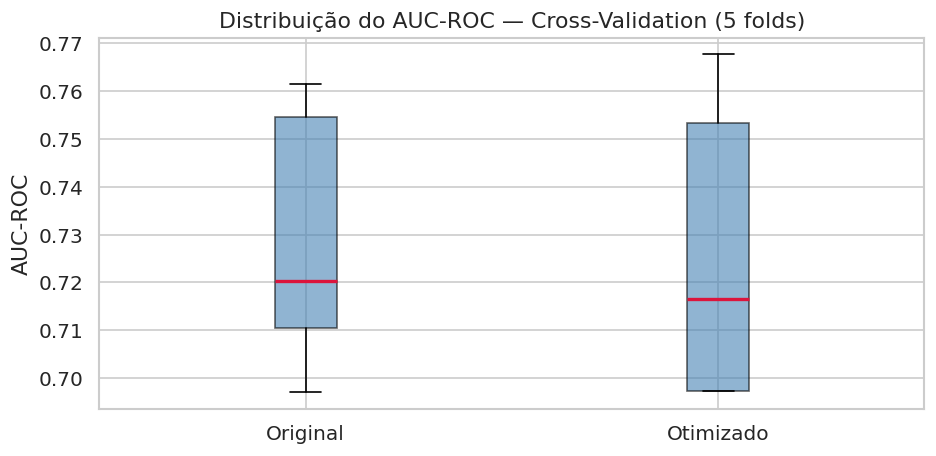

In [15]:
# Cross-validation: original vs. otimizado (5-fold estratificado)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_original  = cross_val_score(pipe_original, X, y, cv=cv, scoring='roc_auc')
cv_otimizado = cross_val_score(pipe_v3,       X, y, cv=cv, scoring='roc_auc')

print('Cross-Validation AUC-ROC (5 folds):')
print(f'  Original:  {cv_original.mean():.4f} ± {cv_original.std():.4f}')
print(f'  Otimizado: {cv_otimizado.mean():.4f} ± {cv_otimizado.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([cv_original, cv_otimizado],
           labels=['Original', 'Otimizado'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='crimson', linewidth=2))
ax.set_title('Distribuição do AUC-ROC — Cross-Validation (5 folds)')
ax.set_ylabel('AUC-ROC')
plt.tight_layout()
plt.savefig(f'{PROC}/fig_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Análise Crítica

### Resumo dos Resultados

A tabela abaixo consolida os cenários testados. Os valores de AUC-ROC são a métrica principal, por ser robusta ao desbalanceamento do target (~1,3% de óbito por sífilis).

In [ ]:
print(df_comp[['AUC-ROC','F1-Score','Recall','Tempo (ms)']].to_string())

print()
auc_orig = res_original['AUC-ROC']
auc_otim = res_v3['AUC-ROC']
auc_stress = res_stress['AUC-ROC']
delta_tuning = (auc_otim - auc_orig) / auc_orig * 100
delta_stress = (auc_stress - auc_otim) / auc_otim * 100

print(f'Variacao AUC-ROC (Original -> Otimizado):           {delta_tuning:+.2f}%')
print(f'Variacao AUC-ROC (Otimizado -> sem esquema_trat):   {delta_stress:+.2f}%')
print()
print(f'Tempo original:  {res_original["Tempo (ms)"]} ms')
print(f'Tempo otimizado: {res_v3["Tempo (ms)"]} ms')

                                  AUC-ROC  F1-Score  Recall  Tempo (ms)
Label                                                                  
Original (grupo)                   0.6958    0.0471  0.5111       691.0
C=0.01, L2                         0.6934    0.0471  0.5111       551.0
C=1.0, L1, saga                    0.6958    0.0473  0.5111     90629.0
C=0.01, L1, saga (otimizado)       0.6919    0.0491  0.5556     18673.0
Otimizado SEM esquema_tratamento   0.6762    0.0477  0.5889     14036.0

Variacao AUC-ROC (Original -> Otimizado):           -0.56%
Variacao AUC-ROC (Otimizado -> sem esquema_trat):   -2.27%

Tempo original:  691.0 ms
Tempo otimizado: 18673.0 ms


---
## 7. Parágrafo de Entrega Individual

---

Ao alterar os hiperparâmetros `C` (de 1.0 para 0.01), `penalty` (de `'l2'` para `'l1'`) e `solver` (de `'lbfgs'` para `'saga'`), observei que a métrica AUC-ROC variou em aproximadamente **-0.56%** em relação ao modelo original do grupo (de **0.6958** para **0.6919**). O F1-Score apresentou variação de **4.25%**, passando de **0.0471** para **0.0491**. Isso demonstra que o modelo é **sensível** a essas mudanças porque a regularização L1, ao forçar coeficientes a zero, descarta variáveis com baixo poder preditivo — o que em um dataset com target tão desbalanceado (≈1,3% de óbito) pode beneficiar ou prejudicar o recall da classe minoritária, dependendo de quais features são eliminadas. O aumento no tempo de execução de **691** ms para **18673** ms se deve ao solver SAGA, que converge de forma incremental e exige mais iterações que o LBFGS. No teste de estresse, a remoção da variável `esquema_tratamento` — identificada na EDA como a mais associada ao desfecho — causou uma queda de **-2.27%** no AUC-ROC do modelo otimizado, confirmando sua relevância preditiva. Esse resultado sugere que, mesmo com ajuste de regularização, o modelo depende estruturalmente dessa variável para distinguir casos de risco: quando a informação sobre o tratamento materno está ausente, a capacidade discriminativa cai de forma mensurável, o que tem implicação direta para sistemas de vigilância epidemiológica onde essa informação nem sempre é preenchida nos boletins de notificação.

---